In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import keras
import tensorflow as tf
import cv2
import math
import time
import shutil 
import random
import numpy as np
import pandas as pd 
from glob import glob
import matplotlib.pyplot as plt
import albumentations as A
from functools import partial

In [4]:
import logging
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

In [5]:
keras.saving.get_custom_objects().clear()
tf.keras.backend.clear_session() ## to clear other sessions in the environment
# tf.config.optimizer.set_jit(True) ## enabling XLA
# policy = tf.keras.mixed_precision.Policy('mixed_float16')
# tf.keras.mixed_precision.set_global_policy(policy)

In [6]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

# Variables

In [7]:
transform_list = ['AutoContrast', 'BoxBlur', 'CLAHE', 'ChannelShuffle', 'ChromaticAberration', 'CoarseDropout', 
                  'ColorJitter', 'Defocus', 'Dilation', 'ElasticTransform', 'Emboss', 'Equalize', 'EqualizeYUV', 
                  'Erosion', 'Frost', 'Gamma', 'GaussNoise', 'GaussianBlur', 'GlassBlur', 'HorizontalFlip', 
                  'HueSaturationValue', 'Invert', 'JPEGCompression', 'MedianBlur', 'MotionBlur', 'OpticalDistortion', 
                  'Original', 'Perspective', 'Posterize', 'RGBShift', 'RandomBrightnessContrast', 'RandomFog', 
                  'RandomGravel', 'RandomGridShuffle', 'RandomRain', 'RandomShadow', 'RandomSnow', 'RandomSunFlare', 
                  'RandomToneCurve', 'Rotate', 'SaltandPepper', 'Scale', 'Sharpen', 'ShearX', 'ShearY', 'ShiftScaleRotate', 
                  'Solarize', 'Speckle', 'ToGray', 'ToSepia', 'Translate', 'VerticalFlip', 'Vignette', 'ZoomBlur']

In [8]:
# transform_list = ['Original']

In [9]:
print(len(transform_list))

54


In [10]:
# threshold = 0.2
end = '_ISIC2019_classification_All_Aug' #_Sel_Aug_Kendall_Th_'+str(threshold)
destination='Results/classification2/2.ISIC2019/Fold1/'
# weights='Results/classification/4.HIBA/18-01-2025-19-18-45_epochs_200_test_acc_93.25_HIBA_No_Aug/epochs_200_test_acc_93.25.keras'

In [11]:
tempfolder="temp_ISIC2019_All_Aug"
isExist = os.path.exists(tempfolder)
if not isExist:
    os.makedirs(tempfolder)

data_root="Datasets/2.ISIC2019/classification/fold1/"
output_path="./"+tempfolder+"/"

train_dir=data_root+"train/"
test_dir=data_root+"test/"

In [12]:
num_classes = len(os.listdir(train_dir))
num_train_images = len(glob(train_dir + '/*/*'))
num_test_images = len(glob(test_dir + '/*/*'))

print("num_classes : ", num_classes)
print("num_train_images : ", num_train_images)
print("num_test_images : ", num_test_images)

num_classes :  8
num_train_images :  17064
num_test_images :  4261


In [13]:
EPOCHS=300
IMG_SIZE=224
BATCH_SIZE=128
LEARNING_RATE=0.0001
dropout_rate=0.3
BUFFER_SIZE=num_train_images
AUTOTUNE = tf.data.AUTOTUNE

In [14]:
# ham10000 = 512
# padufes20 = 464
# derm7pt = 208
# hiba = 192
# ph2 = 40
# mednode = 144

In [15]:
classes=sorted(os.listdir(train_dir))
print(classes)

['AK', 'BCC', 'BKL', 'DF', 'MEL', 'NV', 'SCC', 'VASC']


In [16]:
def parse_image(filename, label):
    image = tf.io.read_file(filename)
    image = tf.image.decode_jpeg(image, channels=3, dct_method="INTEGER_ACCURATE")    
    # image = tf.image.decode_png(image, channels=3)
    # image = tf.image.decode_bmp(image, channels=3)
    # image = tf.image.resize(image, (IMG_SIZE,IMG_SIZE), method="area")
    return image, label

In [17]:
file_names_train=glob(train_dir + '*/*')
random.shuffle(file_names_train)    
lbls_train=[classes.index(name.split('/')[-2]) for name in file_names_train]
train_ds=tf.data.Dataset.from_tensor_slices((file_names_train, lbls_train))
train_ds=train_ds.map(parse_image, num_parallel_calls=AUTOTUNE)

In [18]:
file_names_test=glob(test_dir + '*/*')     
lbls_test=[classes.index(name.split('/')[-2]) for name in file_names_test]
test_ds=tf.data.Dataset.from_tensor_slices((file_names_test, lbls_test))
test_ds=test_ds.map(parse_image, num_parallel_calls=AUTOTUNE)

In [19]:
tr_lb=np.array(lbls_train)
tr_lb_unique=np.unique(tr_lb)
print((np.unique(tr_lb, return_counts=True)))

(array([0, 1, 2, 3, 4, 5, 6, 7]), array([ 484, 2123, 1639,  115, 2972, 9270,  338,  123]))


In [20]:
from sklearn.utils import compute_class_weight
#formula: n_samples / (n_classes * np.bincount(y))
classWeight=compute_class_weight(class_weight="balanced",classes=tr_lb_unique,y=tr_lb)
classWeight=np.round(classWeight,4)
classWeight_dict = dict(zip(tr_lb_unique, classWeight))
print("classWeight : ",classWeight_dict)

classWeight :  {0: 4.407, 1: 1.0047, 2: 1.3014, 3: 18.5478, 4: 0.7177, 5: 0.2301, 6: 6.3107, 7: 17.3415}


# Albumentations

In [21]:
class AutoContrast(A.ImageOnlyTransform):
    def __init__(self, cutoff=3, always_apply=False, p=1.0):
        super().__init__(always_apply, p)
        self.cutoff = cutoff

    def autocontrast_channel(self, channel):
        low_val = np.percentile(channel, self.cutoff)
        high_val = np.percentile(channel, 100 - self.cutoff)

        if high_val > low_val:
            # Scale pixel values to [0, 255]
            scaled = (channel - low_val) * (255.0 / (high_val - low_val))
            return np.clip(scaled, 0, 255).astype(np.uint8)
        else:
            return channel.copy()

    def apply(self, img, **params):
        channels = cv2.split(img)
        auto_channels = [self.autocontrast_channel(ch).astype(np.uint8) for ch in channels]
        h, w = img.shape[:2]
        auto_channels = [cv2.resize(ch, (w, h)) for ch in auto_channels]
        return cv2.merge(auto_channels)

# ===================================

class SaltAndPepperNoise(A.ImageOnlyTransform):
    def __init__(self, salt_prob=0.01, pepper_prob=0.01, always_apply=False, p=1.0):
        super(SaltAndPepperNoise, self).__init__(always_apply, p)
        self.salt_prob = salt_prob
        self.pepper_prob = pepper_prob

    def apply(self,img,**params):
        noisy_img = img.copy()
        salt_mask = np.random.rand(*img.shape[:2]) < self.salt_prob
        noisy_img[salt_mask] = 255
        pepper_mask = np.random.rand(*img.shape[:2]) < self.pepper_prob
        noisy_img[pepper_mask] = 0
        return noisy_img

# ===================================

class SpeckleNoise(A.ImageOnlyTransform):
    def __init__(self, noise_prob=0.1, always_apply=False, p=1.0):
        super(SpeckleNoise, self).__init__(always_apply,p)
        self.noise_prob = noise_prob

    def apply(self, img, **params):
        noise = np.random.normal(0, self.noise_prob, img.shape)
        noisy_img = img + img * noise
        noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)
        return noisy_img

# ===================================

class EmbossEffect(A.ImageOnlyTransform):
    def __init__(self, emboss_strength=1.0, always_apply=False, p=1.0):
        super(EmbossEffect, self).__init__(always_apply, p)
        self.emboss_strength = emboss_strength

    def apply(self, img, **params):
        kernel = np.array([[-2,-1,0],[-1,1,1],[0,1,2]],dtype=np.float32)
        embossed_img = cv2.filter2D(img, -1, kernel * self.emboss_strength)
        embossed_img = np.clip(embossed_img, 0, 255).astype(np.uint8)
        return embossed_img

# ===================================

class EqualizeYUV(A.ImageOnlyTransform):
    def __init__(self, always_apply=False, p=1.0):
        super().__init__(always_apply, p)

    def apply(self, image, **kwargs):
        yuv_image = cv2.cvtColor(image, cv2.COLOR_BGR2YUV)
        y_channel = yuv_image[:, :, 0].astype(np.uint8)
        yuv_image[:, :, 0] = cv2.equalizeHist(y_channel)
        return cv2.cvtColor(yuv_image, cv2.COLOR_YUV2BGR)

# ===================================

class VignetteEffect(A.ImageOnlyTransform):
    def __init__(self, intensity=0.6, always_apply=False, p=1.0):
        super().__init__(always_apply, p)
        self.intensity = intensity

    def apply(self, img, **params):
        rows, cols = img.shape[:2]
        X_resultant_kernel = cv2.getGaussianKernel(cols, cols * self.intensity)
        Y_resultant_kernel = cv2.getGaussianKernel(rows, rows * self.intensity)
        resultant_kernel = Y_resultant_kernel * X_resultant_kernel.T
        # mask = 255 * resultant_kernel / np.linalg.norm(resultant_kernel)
        mask = resultant_kernel / resultant_kernel.max()  # Normalize to range [0, 1]
        output = img.copy()
        for i in range(3):  # Loop over color channels
            output[:, :, i] = np.clip(output[:, :, i] * mask, 0, 255)
        return output.astype(np.uint8)


# ===================================

class FrostEffect(A.ImageOnlyTransform):
    def __init__(self, frost_texture_path="frost/4.jpg", alpha=0.5, always_apply=False, p=1.0):
        super().__init__(always_apply, p)
        self.frost_texture_path = frost_texture_path
        self.alpha = alpha

    def apply(self, img, **params):
        frost_texture = cv2.imread(self.frost_texture_path)
        if frost_texture is None:
            raise ValueError(f"Frost texture image at path {self.frost_texture_path} could not be loaded.")

        frost_texture = cv2.cvtColor(frost_texture, cv2.COLOR_BGR2RGB)
        frost_texture = cv2.resize(frost_texture, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_LINEAR)
        
        if frost_texture.dtype != img.dtype:
            frost_texture = frost_texture.astype(img.dtype)
        
        frosted_image = cv2.addWeighted(img, 1 - self.alpha, frost_texture, self.alpha, 0)
        frosted_image = cv2.cvtColor(frosted_image, cv2.COLOR_RGB2BGR)
        return frosted_image

In [22]:
def augment_train_data(train_ds, transform_list):
    transform_mapping = {
        'AutoContrast': AutoContrast(cutoff=3, p=1.0), 
        'BoxBlur': A.Blur(p=1.0), 
        'CLAHE': A.CLAHE(clip_limit=2.0, p=1.0),
        'ChannelShuffle': A.ChannelShuffle(p=1.0),
        'ChromaticAberration': A.ChromaticAberration(mode='random', p=1.0),
        'CoarseDropout': A.CoarseDropout(num_holes_range=(20,40), hole_height_range=(20,40), hole_width_range=(20,40), p=1.0), 
        'ColorJitter': A.ColorJitter(brightness=(0.8,1.2), contrast=(0.8,1.2), saturation=(0.8,1.2), hue=(-0.5,0.5), p=1.0), 
        'Defocus': A.Defocus(radius=(3,5), p=1.0),
        'Dilation': A.Morphological(scale=(3,5), operation='dilation', p=1.0),
        'ElasticTransform': A.ElasticTransform(p=1.0),
        'Emboss': EmbossEffect(emboss_strength=1.0, p=1.0),
        'Equalize': A.Equalize(p=1.0),
        'EqualizeYUV': EqualizeYUV(p=1.0),
        'Erosion': A.Morphological(scale=(3,5), operation='erosion', p=1.0),
        'Frost': FrostEffect(frost_texture_path="frost/4.jpg", alpha=0.5, p=1.0),
        'Gamma': A.RandomGamma(p=1.0),
        'GaussNoise': A.GaussNoise(p=1.0),
        'GaussianBlur': A.GaussianBlur(p=1.0),
        'GlassBlur': A.GlassBlur(p=1.0),
        'HorizontalFlip': A.HorizontalFlip(p=1.0),
        'HueSaturationValue': A.HueSaturationValue(p=1.0),
        'Invert': A.InvertImg(p=1.0),
        'JPEGCompression': A.ImageCompression(quality_lower=10, quality_upper=30, p=1.0),
        'MedianBlur': A.MedianBlur(p=1.0),
        'MotionBlur': A.MotionBlur(p=1.0),
        'OpticalDistortion': A.OpticalDistortion(distort_limit=0.5, p=1.0),
        'Original': A.NoOp(p=1.0), # original
        'Perspective': A.Perspective(scale=0.2, p=1.0),
        'Posterize': A.Posterize(p=1.0), 
        'RGBShift': A.RGBShift(p=1.0),
        'RandomBrightnessContrast': A.RandomBrightnessContrast(p=1.0),
        'RandomFog': A.RandomFog(fog_coef_lower=0.5, fog_coef_upper=0.8, alpha_coef=0.2, p=1.0),
        'RandomGravel': A.RandomGravel(gravel_roi=(0,0,1,1), number_of_patches=40, p=1.0),
        'RandomGridShuffle': A.RandomGridShuffle(p=1.0),
        'RandomRain': A.RandomRain(brightness_coefficient=0.9, drop_width=1, blur_value=3, p=1.0), 
        'RandomShadow': A.RandomShadow(num_shadows_lower=2, num_shadows_upper=3, shadow_dimension=5, shadow_roi=(0,0,1,1), p=1.0), 
        'RandomSnow': A.RandomSnow(brightness_coeff=2, snow_point_lower=0.4, snow_point_upper=0.7, p=1.0),
        'RandomSunFlare': A.RandomSunFlare(flare_roi=(0,0,1,1), src_radius=150, angle_lower=0.8, p=1.0),
        'RandomToneCurve': A.RandomToneCurve(scale=0.2, p=1.0), 
        'Rotate': A.augmentations.geometric.transforms.Affine(rotate=(-45,45), mode=2, p=1.0),
        'SaltandPepper': SaltAndPepperNoise(salt_prob=0.01, pepper_prob=0.01, p=1.0),
        'Scale': A.augmentations.geometric.transforms.Affine(scale=(0.7,1.3), mode=2, p=1.0),
        'Sharpen': A.Sharpen(p=1.0),
        'ShearX': A.augmentations.geometric.transforms.Affine(shear={'x':(-20,20)}, mode=2, p=1.0),
        'ShearY': A.augmentations.geometric.transforms.Affine(shear={'y':(-20,20)}, mode=2, p=1.0),
        'ShiftScaleRotate': A.ShiftScaleRotate(p=1.0),
        'Solarize': A.Solarize(p=1.0),
        'Speckle': SpeckleNoise(noise_prob=0.1, p=1.0),
        'ToGray': A.ToGray(method='weighted_average', p=1.0),         
        'ToSepia': A.ToSepia(p=1.0),
        'Translate': A.augmentations.geometric.transforms.Affine(translate_percent=(-0.1,0.1), mode=2, p=1.0),
        'VerticalFlip': A.VerticalFlip(p=1.0),
        'Vignette': VignetteEffect(intensity=0.6, p=1.0),
        'ZoomBlur': A.ZoomBlur(p=1.0),  
    }
    
    def aug_fn(image):
        selected_transform_name = random.choice(transform_list)
        selected_transform = transform_mapping[selected_transform_name]
        # image = tf.cast(image, tf.uint8).numpy()

        if selected_transform:
            data = {"image": image}
            augmented = selected_transform(**data)
            aug_img = augmented["image"]
        else:
            aug_img = image

        aug_img = tf.cast(aug_img, tf.float32)
        return tf.image.resize(aug_img, size=[IMG_SIZE, IMG_SIZE], method="area")

    def process_data(image, label):
        aug_img = tf.numpy_function(func=aug_fn, inp=[image], Tout=tf.float32)
        return aug_img, label

    def set_shapes(img, label, img_shape=(IMG_SIZE, IMG_SIZE, 3)):
        img.set_shape(img_shape)
        label.set_shape([])
        return img, label

    ds_alb = train_ds.map(partial(process_data), num_parallel_calls=AUTOTUNE)
    ds_alb = ds_alb.map(set_shapes, num_parallel_calls=AUTOTUNE)
    ds_alb = ds_alb.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds_alb

In [23]:
def augment_test_data(test_ds):
    transforms = A.OneOf([A.NoOp()],p=0.1)
    
    def aug_fn(image):
        data = {"image":image}
        aug_data = transforms(**data)
        aug_img = aug_data["image"]
        aug_img = tf.cast(aug_img, tf.float32)
        return tf.image.resize(aug_img, size=[IMG_SIZE, IMG_SIZE], method="area")

    def process_data(image, label):
        aug_img = tf.numpy_function(func=aug_fn, inp=[image], Tout=tf.float32)
        return aug_img, label
    
    def set_shapes(img, label, img_shape=(IMG_SIZE, IMG_SIZE,3)):
        img.set_shape(img_shape)
        label.set_shape([])
        return img, label
    
    ds_alb = test_ds.map(partial(process_data), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    ds_alb = ds_alb.map(set_shapes, num_parallel_calls=AUTOTUNE)
    ds_alb = ds_alb.batch(BATCH_SIZE)
    return ds_alb

In [24]:
train_alb = augment_train_data(train_ds, transform_list)
test_alb = augment_test_data(test_ds)

In [25]:
def onehot(image,label):
    return image,tf.one_hot(label,num_classes)

In [26]:
def optimize_data(train_alb, test_alb):
    def configure_for_train(ds):
        ds = ds.unbatch()
        ds = ds.shuffle(buffer_size=BUFFER_SIZE)
        ds = ds.map(onehot, num_parallel_calls=AUTOTUNE)
        ds = ds.batch(BATCH_SIZE)
        ds = ds.prefetch(buffer_size=AUTOTUNE)
        return ds
    
    def configure_for_test(ds):
        ds = ds.map(onehot, num_parallel_calls=AUTOTUNE)
        ds = ds.prefetch(buffer_size=AUTOTUNE)
        return ds

    train_ds = configure_for_train(train_alb)
    test_ds = configure_for_test(test_alb)
    
    return train_ds, test_ds

In [27]:
train_dataset, test_dataset = optimize_data(train_alb, test_alb)

In [28]:
def view_image(ds):
    image, label = next(iter(ds)) # extract 1 batch from the dataset
    image = image.numpy()
    label = label.numpy()
    fig = plt.figure(figsize=(14, 10))
    fig.subplots_adjust(wspace=0.05, hspace=0.05)
    fig.tight_layout()
    for i in range(image.shape[0]):        
        ax = fig.add_subplot(int(BATCH_SIZE/16)+1, 16, i+1, xticks=[], yticks=[])
        ax.imshow((image[i]).astype(np.uint8))

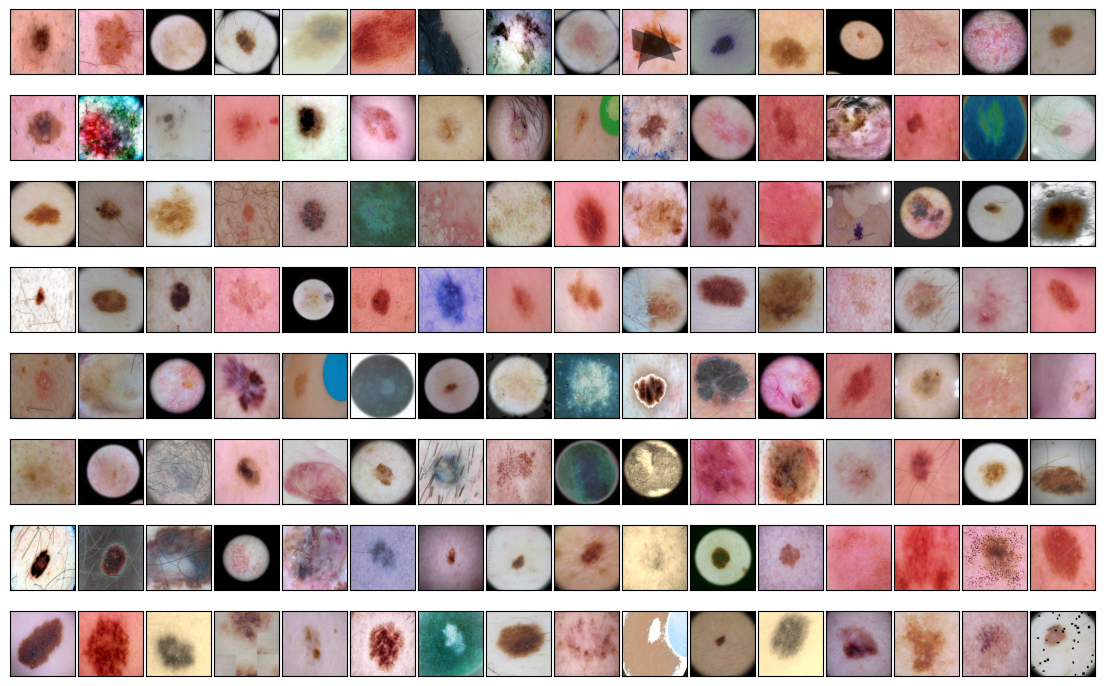

In [29]:
view_image(train_dataset)

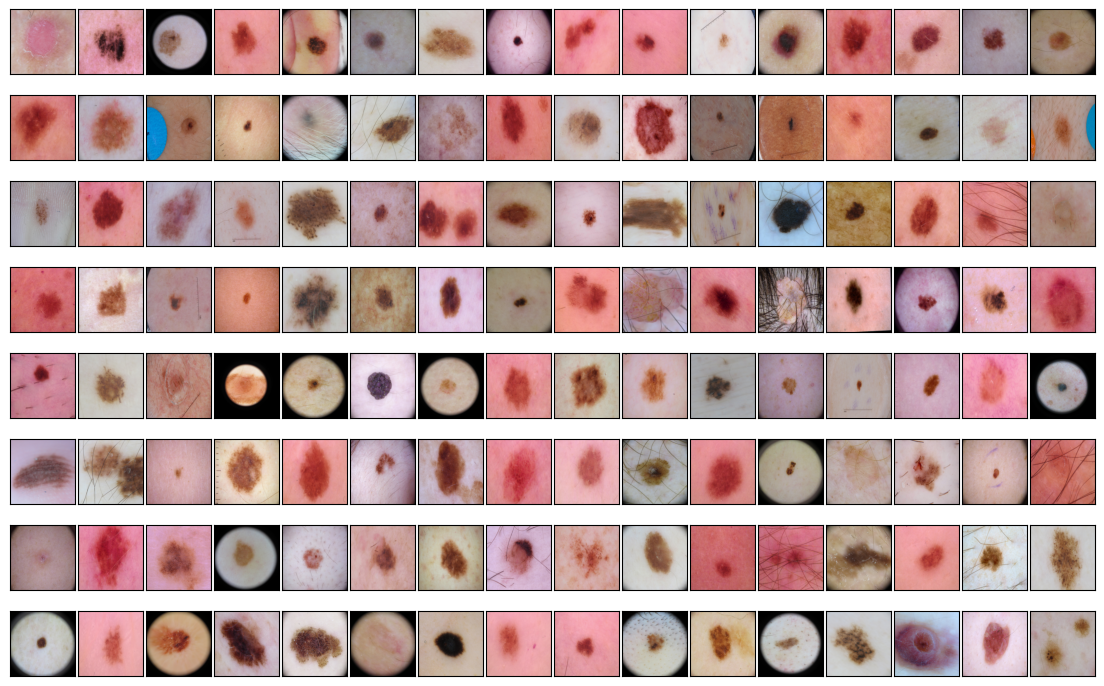

In [30]:
view_image(test_dataset)

# Prepare Model

In [31]:
@keras.saving.register_keras_serializable('SpatialAttention')
class SpatialAttention(tf.keras.layers.Layer):
    def __init__(self, kernel_size=3, **kwargs):
        super(SpatialAttention, self).__init__(**kwargs)
        self.kernel_size = kernel_size
        self.conv = tf.keras.layers.Conv2D(1, kernel_size, padding='same', activation='sigmoid')

    def call(self, inputs):
        avg_out = tf.keras.backend.mean(inputs, axis=-1, keepdims=True)
        max_out = tf.keras.backend.max(inputs, axis=-1, keepdims=True)
        concat = tf.keras.backend.concatenate([avg_out, max_out], axis=-1)
        attention_weights = self.conv(concat)
        return inputs * attention_weights

    def get_config(self):
        config = super().get_config()
        config.update({"kernel_size": self.kernel_size})
        return config

In [32]:
base_model=tf.keras.applications.EfficientNetB0(include_top=False, weights='imagenet', input_shape=(IMG_SIZE,IMG_SIZE,3))
base_model.trainable=True

x = SpatialAttention()(base_model.output)
x = tf.keras.layers.GlobalAveragePooling2D(name="global_avg_pool")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(dropout_rate, name="dropout1")(x)
x = tf.keras.layers.Dense(512, activation="silu", name="pred1")(x) 
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(dropout_rate, name="dropout2")(x)
x = tf.keras.layers.Dense(128, activation="silu", name="pred2")(x) 
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(dropout_rate, name="dropout3")(x)
output = tf.keras.layers.Dense(num_classes, activation="softmax", name="pred3")(x) 
model = tf.keras.Model(base_model.input, output, name="EfficientNetB0")
# model = tf.keras.models.load_model(weights, custom_objects={'SpatialAttention': SpatialAttention})

In [33]:
# till=model.layers.index(model.get_layer('block5a_expand_conv'))+1    
# for layer in model.layers[:till]:
#     layer.trainable=False
# for layer in model.layers[till:]:
#     layer.trainable=True
    # if isinstance(layer, tf.keras.layers.BatchNormalization):
    #     layer.trainable = False

In [34]:
# i=1
# j=len(model.layers)
# for x in model.layers:
#     print(i, j, x.name, x.output.shape, x.trainable)
#     i=i+1
#     j=j-1

# Model Information

In [35]:
trainable_count = int(np.sum([tf.keras.backend.count_params(w) for w in model.trainable_weights]))
non_trainable_count = int(np.sum([tf.keras.backend.count_params(w) for w in model.non_trainable_weights]))
total_count = trainable_count + non_trainable_count

print('Total params: {:,}'.format(total_count))
print('Trainable params: {:,}'.format(trainable_count))
print('Non-trainable params: {:,}'.format(non_trainable_count))

Total params: 4,779,838
Trainable params: 4,733,975
Non-trainable params: 45,863


In [36]:
from tensorflow.python.profiler.model_analyzer import profile
from tensorflow.python.profiler.option_builder import ProfileOptionBuilder

def get_flops(model):
  forward_pass = tf.function(model.call, input_signature=[tf.TensorSpec(shape=(1,) + model.input_shape[1:])])
  graph_info = profile(forward_pass.get_concrete_function().graph, options=ProfileOptionBuilder.float_operation())
  flops = graph_info.total_float_ops
  return flops

In [37]:
flops = get_flops(model)
macs = flops / 2


=========================Options=============================
-max_depth                  10000
-min_bytes                  0
-min_peak_bytes             0
-min_residual_bytes         0
-min_output_bytes           0
-min_micros                 0
-min_accelerator_micros     0
-min_cpu_micros             0
-min_params                 0
-min_float_ops              1
-min_occurrence             0
-step                       -1
-order_by                   float_ops
-account_type_regexes       .*
-start_name_regexes         .*
-trim_name_regexes          
-show_name_regexes          .*
-hide_name_regexes          
-account_displayed_op_only  true
-select                     float_ops
-output                     stdout:

==================Model Analysis Report======================

Doc:
scope: The nodes in the model graph are organized by their names, which is hierarchical like filesystem.
flops: Number of float operations. Note: Please read the implementation for the math behind it.

Profi

In [38]:
print(macs/10 ** 9)

0.401186798
(2.30k/2.30k flops)
  block6c_bn_1/batchnorm/Rsqrt (2.30k/2.30k flops)
  block6c_expand_bn_1/batchnorm/Rsqrt (2.30k/2.30k flops)
  block6d_bn_1/batchnorm/Rsqrt (2.30k/2.30k flops)
  block6d_expand_bn_1/batchnorm/Rsqrt (2.30k/2.30k flops)
  block7a_bn_1/batchnorm/Rsqrt (2.30k/2.30k flops)
  block7a_expand_bn_1/batchnorm/Rsqrt (2.30k/2.30k flops)
  pred3_1/MatMul (2.05k/2.05k flops)
  spatial_attention_1/conv2d_1/convolution (1.76k/1.76k flops)
  block2b_se_expand_1/convolution (1.73k/1.73k flops)
  block2b_se_reduce_1/convolution (1.73k/1.73k flops)
  block3a_se_expand_1/convolution (1.73k/1.73k flops)
  block3a_se_reduce_1/convolution (1.73k/1.73k flops)
  block5b_bn_1/batchnorm/Rsqrt (1.34k/1.34k flops)
  block5b_expand_bn_1/batchnorm/Rsqrt (1.34k/1.34k flops)
  block5c_bn_1/batchnorm/Rsqrt (1.34k/1.34k flops)
  block5c_expand_bn_1/batchnorm/Rsqrt (1.34k/1.34k flops)
  block6a_bn_1/batchnorm/Rsqrt (1.34k/1.34k flops)
  block6a_expand_bn_1/batchnorm/Rsqrt (1.34k/1.34k flops

In [39]:
print(flops/10 ** 9)

0.802373596


# Train Model

In [40]:
regularizer=tf.keras.regularizers.l2(0.00001)
for layer in model.layers:
    for attr in ['kernel_regularizer']:
        if hasattr(layer, attr):
            setattr(layer, attr, regularizer)

In [41]:
optimizer_fn = tf.keras.optimizers.AdamW(learning_rate=LEARNING_RATE, clipnorm=2.0)  
metrics = [tf.keras.metrics.CategoricalAccuracy(name='accuracy')]
loss_fn = tf.keras.losses.CategoricalFocalCrossentropy(gamma=5, label_smoothing=0.05)
model.compile(optimizer = optimizer_fn, loss = loss_fn, metrics = metrics)

In [42]:
ModelCheckPoint=tf.keras.callbacks.ModelCheckpoint(
    filepath=output_path+'EfficientNetB0-{epoch:03d}-{val_accuracy:.4f}.weights.h5',
    monitor='val_accuracy', verbose=1, save_best_only=True, save_weights_only=True)

In [43]:
def convert(seconds):
    hour = seconds // 3600
    seconds %= 3600
    minutes = seconds // 60
    seconds %= 60     
    return "%d:%02d:%02d" % (hour, minutes, seconds)

In [44]:
%%time
t1=time.time()
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    class_weight=classWeight_dict,
    validation_data=test_dataset,
    callbacks=[ModelCheckPoint] 
)
t2=time.time()
time_taken = t2-t1
print("Time taken : ",convert(time_taken)," hh:mm:ss")

Epoch 1/300
      1/Unknown 363s 363s/step - accuracy: 0.1641 - loss: 0.5346

I0000 00:00:1743339235.132732 1498321 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


    134/Unknown 450s 652ms/step - accuracy: 0.1691 - loss: 0.5185
Epoch 1: val_accuracy improved from -inf to 0.19315, saving model to ./temp_ISIC2019_All_Aug/EfficientNetB0-001-0.1931.weights.h5
134/134 ━━━━━━━━━━━━━━━━━━━━ 491s 960ms/step - accuracy: 0.1692 - loss: 0.5182 - val_accuracy: 0.1931 - val_loss: 0.2664
Epoch 2/300
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.2282 - loss: 0.3800
Epoch 2: val_accuracy improved from 0.19315 to 0.38184, saving model to ./temp_ISIC2019_All_Aug/EfficientNetB0-002-0.3818.weights.h5
134/134 ━━━━━━━━━━━━━━━━━━━━ 259s 274ms/step - accuracy: 0.2283 - loss: 0.3798 - val_accuracy: 0.3818 - val_loss: 0.2195
Epoch 3/300
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.2663 - loss: 0.2917
Epoch 3: val_accuracy improved from 0.38184 to 0.45740, saving model to ./temp_ISIC2019_All_Aug/EfficientNetB0-003-0.4574.weights.h5
134/134 ━━━━━━━━━━━━━━━━━━━━ 248s 254ms/step - accuracy: 0.2663 - loss: 0.2917 - val_accuracy: 0.4574 - val_loss: 0.22

In [45]:
for x in sorted(os.listdir(output_path))[:-3]:
    os.remove(output_path+x)

In [46]:
model.load_weights(output_path+sorted(os.listdir(output_path))[-1]) 

In [47]:
test_loss, test_accuracy_by_evaluate = model.evaluate(test_dataset)

34/34 ━━━━━━━━━━━━━━━━━━━━ 21s 562ms/step - accuracy: 0.9007 - loss: 0.0445


In [48]:
test_accuracy_by_evaluate_rounded = round((test_accuracy_by_evaluate)*100, 2)

In [49]:
Hist = {'hist' : history.history} 
df = pd.DataFrame.from_dict(Hist)  
df.to_csv(output_path+'Hist.csv', index = True, header=True)  

In [50]:
num_epoch = len(history.history['loss'])
executed_epoch_count = len(history.history['loss'])

In [51]:
savedfilename="epochs_{}".format(executed_epoch_count)+"_test_acc_{}".format(test_accuracy_by_evaluate_rounded)

In [52]:
name=output_path+"{}".format(savedfilename)+".keras"
model.save(name)

In [53]:
name_weights=output_path+"{}".format(savedfilename)+".weights.h5"
model.save_weights(name_weights)

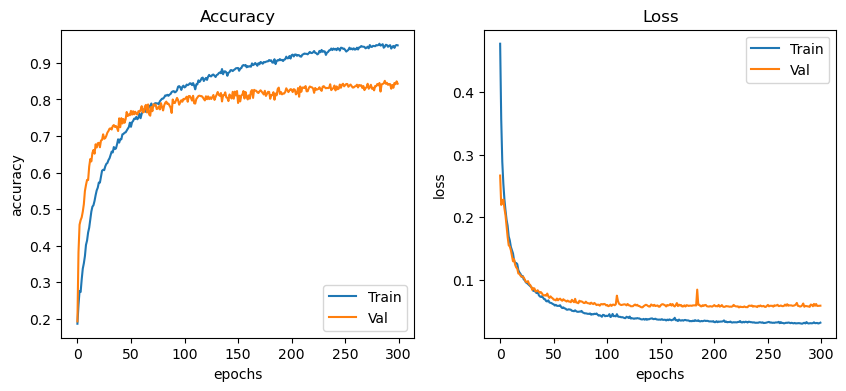

In [54]:
figpath=output_path+"{}".format(savedfilename)+".pdf"
fig = plt.figure(figsize=(10,4))
epochs_range = range(len(history.history['loss']))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history.history['accuracy'], label='Train')
plt.plot(epochs_range, history.history['val_accuracy'], label='Val')
plt.legend(loc='lower right')
plt.title('Accuracy')
plt.xlabel('epochs')
plt.ylabel('accuracy')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history.history['loss'], label='Train')
plt.plot(epochs_range, history.history['val_loss'], label='Val')
plt.legend(loc='upper right')
plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()
fig.savefig(figpath, format='pdf', bbox_inches='tight')

# Predictions

In [55]:
# predictions=model.predict(test_dataset)
# y_pred = np.argmax(predictions, axis=1)
# y_true = np.concatenate([y for x, y in test_dataset], axis=0)
# y_prob = predictions

# same = 0
# total = len(y_true)

# for i in range(total):
#     if y_true[i] == y_pred[i]:
#         same=same+1
        
# test_acc = same/total*100
# res='{:.2f}'.format(test_acc)
# print(same)
# print(total)
# print(res)

In [56]:
%%time
predi=model.predict(test_dataset)
y_p = np.argmax(predi, axis=1)
y_t = np.concatenate([y for x, y in test_dataset], axis=0)
y_tt = np.argmax(y_t, axis=1)
y_pr = predi

same = 0
total = len(y_tt)

for i in range(total):
    if y_tt[i] == y_p[i]:
        same=same+1
        
test_acc = same/total*100
res='{:.2f}'.format(test_acc)
print(same)
print(total)
print(res)

34/34 ━━━━━━━━━━━━━━━━━━━━ 36s 258ms/step
3625
4261
85.07
CPU times: user 5min 3s, sys: 21.1 s, total: 5min 24s
Wall time: 54.6 s


In [57]:
y_pred = y_p
y_true = y_tt
y_prob = y_pr

In [58]:
# %%time
# tm = []
# correctly_classified = {"y_true":[], "y_pred":[], "y_prob":[], "filename":[], "inference_time":[]}
# mis_classified = {"orig":[],"pred":[], "prob":[], "filename":[], "inference_time":[]}
# for i in file_names_test:
#     image=tf.keras.utils.load_img(i)
#     input_arr=tf.keras.utils.img_to_array(image)
#     img_resized=tf.image.resize(input_arr, size=(IMG_SIZE, IMG_SIZE))
#     input_img=np.array([img_resized])  
#     start_time=time.time()  
#     predictions=model(input_img, training=False)
#     end_time=time.time()
#     t=1000*(end_time-start_time)
#     tm.append(t)
#     pr_fnl = np.argmax(predictions, axis=1)[0]
#     lbl=classes.index(i.split('/')[-2])
    
#     if lbl == pr_fnl:
#         correctly_classified["y_true"].append(lbl)
#         correctly_classified["y_pred"].append(pr_fnl)
#         correctly_classified["y_prob"].append(predictions)
#         correctly_classified["filename"].append(i)
#         correctly_classified["inference_time"].append(t)
#     else:
#         mis_classified["orig"].append(lbl)
#         mis_classified["pred"].append(pr_fnl)
#         mis_classified["prob"].append(predictions)
#         mis_classified["filename"].append(i)
#         mis_classified["inference_time"].append(t)

# print(len(correctly_classified["y_true"]))
# print(len(y_t))
# test_acc1 = len(correctly_classified["y_true"])/len(y_t)*100
# print('{:.2f}'.format(test_acc1))

In [59]:
# print(f"Average (ms) : {np.mean(tm)}")
# print(f"Std dev (ms) : {np.std(tm)}")
# print(f"Min     (ms) : {np.min(tm)}")
# print(f"Max     (ms) : {np.max(tm)}")

In [60]:
# df11 = pd.DataFrame.from_dict(correctly_classified) 
# df11.to_csv(output_path+'correctly_classified.csv', index = True, header=True)

# df22 = pd.DataFrame.from_dict(mis_classified) 
# df22.to_csv(output_path+'mis_classified.csv', index = True, header=True)

In [61]:
# y_pred1=correctly_classified["y_pred"]
# y_true1=correctly_classified["y_true"]  
# y_prob1=correctly_classified["y_prob"]

# y_pred2=mis_classified["pred"]
# y_true2=mis_classified["orig"]  
# y_prob2=mis_classified["prob"]

# y_pred=y_pred1+y_pred2
# y_true=y_true1+y_true2
# y_prob=y_prob1+y_prob2

In [62]:
y_test = tf.keras.utils.to_categorical(y_true)

In [63]:
from sklearn.metrics import confusion_matrix
confusion = confusion_matrix(y_true, y_pred)
print('Confusion Matrix\n')
print(confusion)

Confusion Matrix

[[  99    7    6    0    3    1    5    0]
 [  17  475   11    0    8   13    3    3]
 [  15   15  291    3   31   49    5    0]
 [   0    1    1   20    1    3    1    1]
 [  11   19   33    0  525  151    2    1]
 [  10   30   45    4   92 2131    1    4]
 [   6    5    5    0    5    5   58    0]
 [   0    0    0    1    0    3    0   26]]


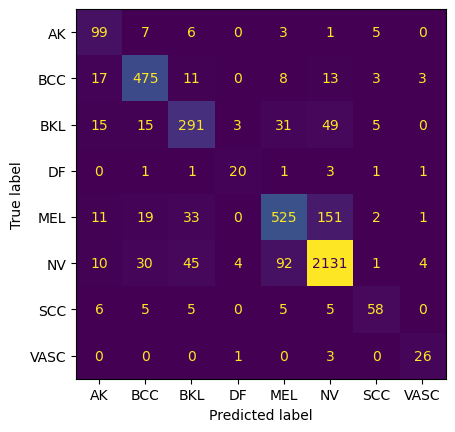

In [64]:
fig_path=output_path+"confusion_matrix.pdf"
from sklearn.metrics import ConfusionMatrixDisplay
cm_display=ConfusionMatrixDisplay(confusion, display_labels=classes).plot(colorbar=False)
fig=cm_display.figure_
fig.savefig(fig_path, format='pdf', bbox_inches='tight')

In [65]:
from sklearn.metrics import confusion_matrix
confusion = confusion_matrix(y_true, y_pred, normalize='all')
print('Confusion Matrix\n')
print(confusion)

Confusion Matrix

[[2.32339826e-02 1.64280685e-03 1.40812016e-03 0.00000000e+00
  7.04060080e-04 2.34686693e-04 1.17343347e-03 0.00000000e+00]
 [3.98967379e-03 1.11476179e-01 2.58155363e-03 0.00000000e+00
  1.87749355e-03 3.05092701e-03 7.04060080e-04 7.04060080e-04]
 [3.52030040e-03 3.52030040e-03 6.82938277e-02 7.04060080e-04
  7.27528749e-03 1.14996480e-02 1.17343347e-03 0.00000000e+00]
 [0.00000000e+00 2.34686693e-04 2.34686693e-04 4.69373387e-03
  2.34686693e-04 7.04060080e-04 2.34686693e-04 2.34686693e-04]
 [2.58155363e-03 4.45904717e-03 7.74466088e-03 0.00000000e+00
  1.23210514e-01 3.54376907e-02 4.69373387e-04 2.34686693e-04]
 [2.34686693e-03 7.04060080e-03 1.05609012e-02 9.38746773e-04
  2.15911758e-02 5.00117343e-01 2.34686693e-04 9.38746773e-04]
 [1.40812016e-03 1.17343347e-03 1.17343347e-03 0.00000000e+00
  1.17343347e-03 1.17343347e-03 1.36118282e-02 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 2.34686693e-04
  0.00000000e+00 7.04060080e-04 0.00000000e+0

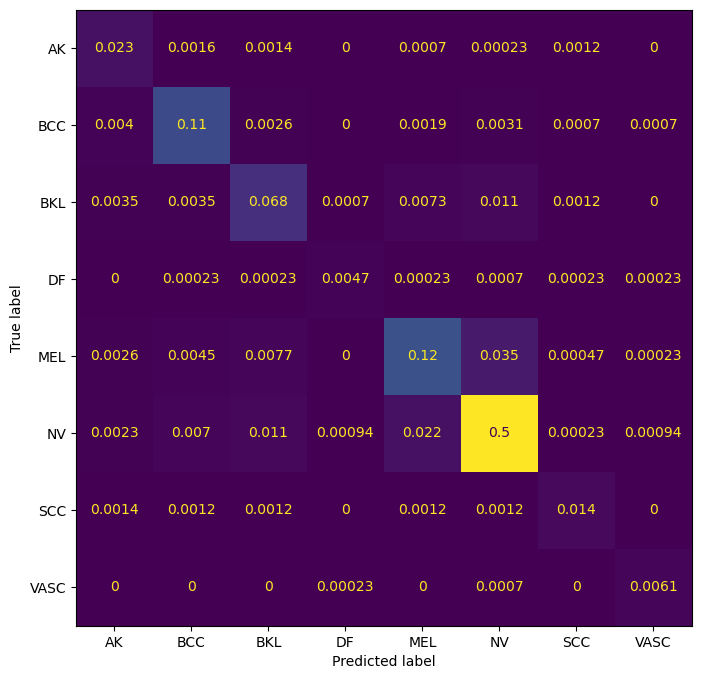

In [66]:
fig_path=output_path+"confusion_matrix1.pdf"
from sklearn.metrics import ConfusionMatrixDisplay
cm_display=ConfusionMatrixDisplay(confusion, display_labels=classes).plot(colorbar=False)
fig=cm_display.figure_
fig.set_figwidth(8)
fig.set_figheight(8)
fig.savefig(fig_path, format='pdf', bbox_inches='tight')

In [67]:
y_prob = np.array(y_prob)
y_prob_new = y_prob.reshape(y_pr.shape)

In [68]:
from sklearn.metrics import roc_auc_score
targetnames=classes
fpr = {}
tpr = {}
roc_auc = {}
for i in range(num_classes):
    r = roc_auc_score(y_test[:, i], y_prob_new[:, i])
    print("The ROC AUC score of "+targetnames[i]+" is: "+str(r))

The ROC AUC score of AK is: 0.9760170878747954
The ROC AUC score of BCC is: 0.9866296152076179
The ROC AUC score of BKL is: 0.9421479839641299
The ROC AUC score of DF is: 0.9704363673180115
The ROC AUC score of MEL is: 0.9336723478015762
The ROC AUC score of NV is: 0.9546871087027179
The ROC AUC score of SCC is: 0.8807870766214075
The ROC AUC score of VASC is: 0.9784448121011581


In [69]:
from sklearn.metrics import roc_curve, auc
fpr = {}
tpr = {}
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_prob_new[:, i], drop_intermediate=False)
    roc_auc[i] = auc(fpr[i], tpr[i])

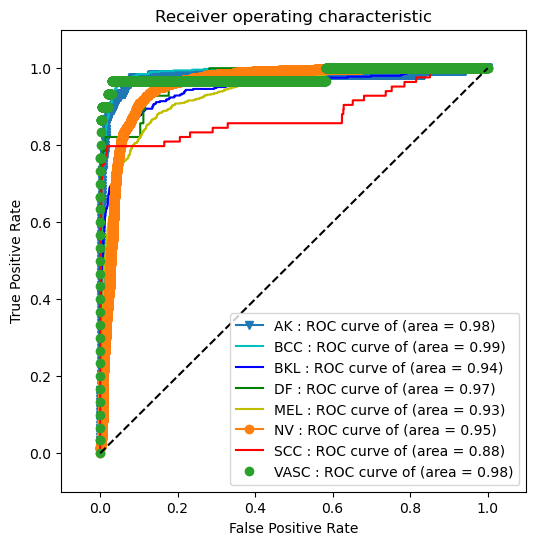

In [70]:
fig_path_roc=output_path+"roc_auc_curve.pdf"
fig = plt.figure(figsize=(6,6))
l0="{}".format(targetnames[0])+" : ROC curve of (area = {}".format(round(roc_auc[0],2))+")"
l1="{}".format(targetnames[1])+" : ROC curve of (area = {}".format(round(roc_auc[1],2))+")"
l2="{}".format(targetnames[2])+" : ROC curve of (area = {}".format(round(roc_auc[2],2))+")"
l3="{}".format(targetnames[3])+" : ROC curve of (area = {}".format(round(roc_auc[3],2))+")"
l4="{}".format(targetnames[4])+" : ROC curve of (area = {}".format(round(roc_auc[4],2))+")"
l5="{}".format(targetnames[5])+" : ROC curve of (area = {}".format(round(roc_auc[5],2))+")"
l6="{}".format(targetnames[6])+" : ROC curve of (area = {}".format(round(roc_auc[6],2))+")"
l7="{}".format(targetnames[7])+" : ROC curve of (area = {}".format(round(roc_auc[7],2))+")"
# l8="{}".format(targetnames[8])+" : ROC curve of (area = {}".format(round(roc_auc[8],2))+")"
plt.plot(fpr[0], tpr[0],'v-',label=l0)
plt.plot(fpr[1], tpr[1],'c' ,label=l1)
plt.plot(fpr[2], tpr[2],'b' ,label=l2)
plt.plot(fpr[3], tpr[3],'g' ,label=l3)
plt.plot(fpr[4], tpr[4],'y' ,label=l4)
plt.plot(fpr[5], tpr[5],'o-',label=l5)
plt.plot(fpr[6], tpr[6],'r' ,label=l6)
plt.plot(fpr[7], tpr[7],'o' ,label=l7)
# plt.plot(fpr[8], tpr[8],'c' ,label=l8)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([-0.1, 1.1])
plt.ylim([-0.1, 1.1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()
fig.savefig(fig_path_roc, format='pdf', bbox_inches='tight')

In [71]:
from sklearn.metrics import accuracy_score
accuracy_score = accuracy_score(y_true, y_pred)
print('Accuracy: {}'.format(accuracy_score))

Accuracy: 0.8507392630837831


In [72]:
from sklearn.metrics import classification_report
classification_report = classification_report(y_true, y_pred, 
    target_names=targetnames, zero_division=0)
print('Classification Report : \n')
print(classification_report)

Classification Report : 

              precision    recall  f1-score   support

          AK       0.63      0.82      0.71       121
         BCC       0.86      0.90      0.88       530
         BKL       0.74      0.71      0.73       409
          DF       0.71      0.71      0.71        28
         MEL       0.79      0.71      0.75       742
          NV       0.90      0.92      0.91      2317
         SCC       0.77      0.69      0.73        84
        VASC       0.74      0.87      0.80        30

    accuracy                           0.85      4261
   macro avg       0.77      0.79      0.78      4261
weighted avg       0.85      0.85      0.85      4261



In [73]:
from sklearn.metrics import precision_score, recall_score, f1_score

In [74]:
micro_precision = precision_score(y_true, y_pred, average='micro', zero_division=0)
macro_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
weighted_precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"Micro Precision: {micro_precision}")
print(f"Macro Precision: {macro_precision}")
print(f"Weighted Precision: {weighted_precision}")

Micro Precision: 0.8507392630837831
Macro Precision: 0.7692356861779521
Weighted Precision: 0.850566748489083


In [75]:
micro_recall = recall_score(y_true, y_pred, average='micro', zero_division=0)
macro_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
weighted_recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"Micro Recall: {micro_recall}")
print(f"Macro Recall: {macro_recall}")
print(f"Weighted Recall: {weighted_recall}")

Micro Recall: 0.8507392630837831
Macro Recall: 0.7905748997262261
Weighted Recall: 0.8507392630837831


In [76]:
micro_f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f"Micro F1: {micro_f1}")
print(f"Macro F1: {macro_f1}")
print(f"Weighted F1: {weighted_f1}")

Micro F1: 0.8507392630837831
Macro F1: 0.7770543663609215
Weighted F1: 0.8497109562213374


In [77]:
from sklearn.metrics import roc_auc_score
micro_roc_auc_ovr = roc_auc_score(y_test, y_prob_new, multi_class="ovr",average="micro")
macro_roc_auc_ovr = roc_auc_score(y_test, y_prob_new, multi_class="ovr",average="macro")
weighted_roc_auc_ovr = roc_auc_score(y_true, y_prob_new, multi_class='ovr',average='weighted')

print(f"Micro-averaged One-vs-Rest ROC AUC score: {micro_roc_auc_ovr}")
print(f"Macro-averaged One-vs-Rest ROC AUC score: {macro_roc_auc_ovr}")
print(f"Weighted One-vs-Rest ROC AUC score: {weighted_roc_auc_ovr}")

Micro-averaged One-vs-Rest ROC AUC score: 0.9782141004363527
Macro-averaged One-vs-Rest ROC AUC score: 0.9528527999489268
Weighted One-vs-Rest ROC AUC score: 0.9532168221429995


In [78]:
from sklearn.metrics import balanced_accuracy_score
balanced_accuracy_score = balanced_accuracy_score(y_true, y_pred)
print('balanced_accuracy_score : ', balanced_accuracy_score)

balanced_accuracy_score :  0.7905748997262261


In [79]:
from sklearn.metrics import jaccard_score
jaccard_score = jaccard_score(y_true, y_pred, average='weighted')
print('jaccard_score : ', jaccard_score)

jaccard_score :  0.7468913202491089


In [80]:
specificity = []
cm = np.array(confusion_matrix(y_true, y_pred))
for i in range(cm.shape[0]):
    tn = np.sum(cm) - np.sum(cm[i, :]) - np.sum(cm[:, i]) + cm[i, i]
    fp = np.sum(cm[:, i]) - cm[i, i]
    specificity_i = tn / (tn + fp) if (tn + fp) > 0 else 0
    specificity_i = np.round(specificity_i, 6)
    specificity.append(specificity_i)

print(f'Specificity for each class: {specificity}')
spec_unweighted=np.round(np.average(specificity), 6)
spec_weighted=np.round(np.average(specificity, weights=list(classWeight_dict.values())), 6)
print(spec_unweighted)
print(spec_weighted)

Specificity for each class: [0.985749, 0.979362, 0.97378, 0.99811, 0.960216, 0.884259, 0.99593, 0.997873]
0.97191
0.994575


In [81]:
from sklearn.metrics import multilabel_confusion_matrix
multilabel_confusion_matrix = multilabel_confusion_matrix(y_true, y_pred)
print('multilabel_confusion_matrix : \n', multilabel_confusion_matrix)

multilabel_confusion_matrix : 
 [[[4081   59]
  [  22   99]]

 [[3654   77]
  [  55  475]]

 [[3751  101]
  [ 118  291]]

 [[4225    8]
  [   8   20]]

 [[3379  140]
  [ 217  525]]

 [[1719  225]
  [ 186 2131]]

 [[4160   17]
  [  26   58]]

 [[4222    9]
  [   4   26]]]


# Saving All Results

In [82]:
import pandas as pd  
Labels={'File_Name':[],'True_Label':[],'Predicted_Label':[],'Prediction_Probability':[]}

for i in range(len(file_names_test)): 
    Labels['File_Name'].append(file_names_test[i])
    Labels['True_Label'].append(y_true[i])
    Labels['Predicted_Label'].append(y_pred[i])
    Labels['Prediction_Probability'].append(y_prob_new[i])

df = pd.DataFrame.from_dict(Labels) 
df.to_csv(output_path+'Labels.csv', index = False, header=True)

In [83]:
Class_Weights = {'classWeight' : classWeight}
df = pd.DataFrame.from_dict(Class_Weights) 
df.to_csv(output_path+'Class_Weights.csv', index = True, header=True)

In [84]:
Hist = {'hist' : history.history}
df = pd.DataFrame.from_dict(Hist) 
df.to_csv(output_path+'Hist.csv', index = True, header=True)

In [85]:
Hyperparameters = {
    'Number_of_Classes' : num_classes,
    'Number_of_Train_Images' : num_train_images,
    'Number_of_Test_Images' : num_test_images,
    'BATCH_SIZE' : BATCH_SIZE,
    'IMG_SIZE' : IMG_SIZE,
    'LEARNING_RATE' : LEARNING_RATE,
    'EPOCHS' : EPOCHS,
    'Number_of_Epoch_Actually_Executed' : len(history.history['loss']),            
}
df = pd.DataFrame.from_records([Hyperparameters]).transpose()
df.to_csv(output_path+'Hyperparameters.csv', index = True, header=False)

In [86]:
Results_in_Program = {
    'Time_Taken_for_execution_(in_seconds)' : time_taken,
    'Test_Accuracy_by_Model_Evaluate_Method' : test_accuracy_by_evaluate,        
    'Number_of_Correct_Predictions' : same,
    'Number_of_Total_Predictions' : total,
    'Test_Accuracy_by_Manual_Matching' : test_acc,
    'Test_Accuracy_Result_Adjusted' : res 
}
df = pd.DataFrame.from_records([Results_in_Program]).transpose()
df.to_csv(output_path+'Results_in_Program.csv', index = True, header=False)

In [87]:
Results = {
    'accuracy_score' : accuracy_score,
    'balanced_accuracy_score' : balanced_accuracy_score,
    'jaccard_score' : jaccard_score, 
    
    'micro_precision':micro_precision,
    'macro_precision':macro_precision,
    'weighted_precision':weighted_precision,
    
    'micro_recall':micro_recall,
    'macro_recall':macro_recall,
    'weighted_recall':weighted_recall,
    
    'micro_f1':micro_f1,
    'macro_f1':macro_f1,
    'weighted_f1':weighted_f1,
    
    'micro_roc_auc_ovr': micro_roc_auc_ovr,
    'macro_roc_auc_ovr': macro_roc_auc_ovr,
    'weighted_roc_auc_ovr':weighted_roc_auc_ovr,
    
    'multilabel_confusion_matrix' : multilabel_confusion_matrix,
}
df = pd.DataFrame.from_records([Results]).transpose()
df.to_csv(output_path+'Results.csv', index = True, header=False)

In [88]:
classification_report = {'classification_report' : classification_report}
df = pd.DataFrame.from_records([classification_report]).transpose()
df.to_csv(output_path+'classification_report.csv', index = True, header=False)

In [89]:
Model_Name = model.name
Input_Shape = model.input_shape
Top_Layer_Dropout_Rate = dropout_rate
Model_Loss = type(model.loss)
Model_Optimizer = type(model.optimizer)
Model_Metrics_Names = model.metrics_names
Model_Metrics = model.metrics
Model_Trainable_Parameters_Count = trainable_count
Model_Non_Trainable_Parameters_Count = non_trainable_count
Model_Total_Parameters_Count = total_count
Model_Output_Shape = model.output_shape

Model_Parameters = {
    'Model_Name' : Model_Name,
    'Input_Shape' : Input_Shape,
    'Top_Layer_Dropout_Rate' : Top_Layer_Dropout_Rate,
    'Model_Loss' : Model_Loss,
    'Model_Optimizer' : Model_Optimizer,
    'LEARNING_RATE' : LEARNING_RATE,
    'Model_Metrics_Names' : Model_Metrics_Names,
    'Model_Metrics' : Model_Metrics,
    'Model_Trainable_Parameters_Count' : Model_Trainable_Parameters_Count,
    'Model_Non_Trainable_Parameters_Count' : Model_Non_Trainable_Parameters_Count,
    'Model_Total_Parameters_Count' : Model_Total_Parameters_Count,
    'Model_Output_Shape' : Model_Output_Shape
}
df = pd.DataFrame.from_records([Model_Parameters]).transpose()
df.to_csv(output_path+'Model_Parameters.csv', index = True, header=False)

# GradCAM

In [90]:
for im, lb in test_dataset.take(1):
    sample_test_img = im.numpy()
    sample_test_lbl = lb.numpy()

In [91]:
img_idx=np.random.randint(sample_test_img.shape[0])

In [92]:
sa_model = tf.keras.models.Model(model.inputs,model.get_layer('spatial_attention').output)
sa_maps = sa_model.predict(sample_test_img)

4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step


In [93]:
sum_attnmap = np.sum(sa_maps[img_idx],2)
sum_attnmap.shape

(7, 7)

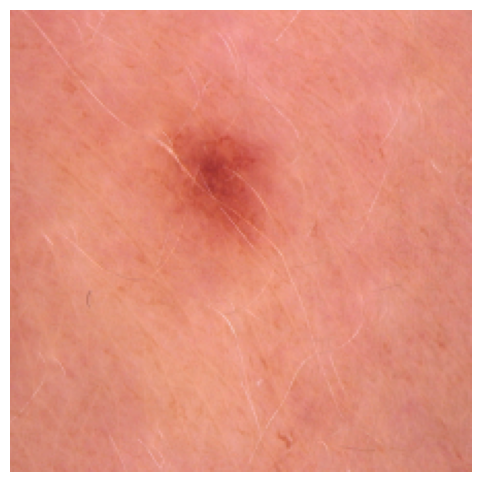

In [94]:
%matplotlib inline
fig_test_img=output_path+'fig_test_img.pdf'
fig=plt.figure(figsize=(6,6))
imgplot=plt.imshow(sample_test_img[img_idx].astype('uint8'))
plt.axis('off')
plt.show()
fig.savefig(fig_test_img, format='pdf', bbox_inches='tight')

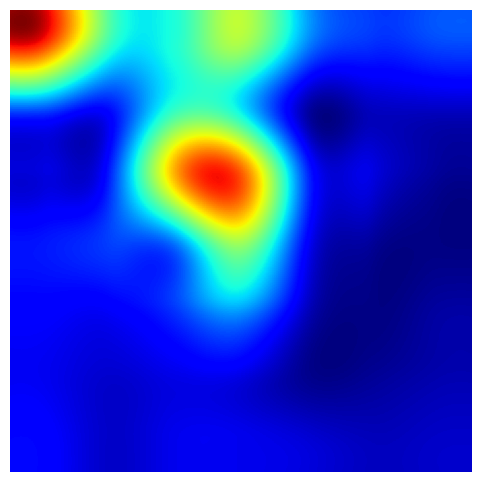

In [95]:
fig_heatmap=output_path+'fig_heatmap.pdf'
fig=plt.figure(figsize=(6,6))
#plt.imshow(sample_test_img[img_idx].astype('uint8'),alpha=1.0)
plt.imshow(cv2.resize(sum_attnmap,(IMG_SIZE,IMG_SIZE),interpolation=cv2.INTER_CUBIC),cmap='jet',alpha=1.0)
plt.axis('off')
plt.show()
fig.savefig(fig_heatmap, format='pdf', bbox_inches='tight')

# Model Plot

In [96]:
tf.keras.utils.plot_model(model, to_file=output_path+'model.pdf', 
    show_shapes=True,    
    show_dtype=True,
    show_layer_names=True,
    rankdir="TB",
    expand_nested=True,
    dpi=1200,
    layer_range=None,
    show_layer_activations=True,
)

# Move temp to saved_models

In [97]:
from pytz import timezone 
from datetime import datetime
cur_time=datetime.now(timezone("Asia/Kolkata")).strftime('%d-%m-%Y-%H-%M-%S')
name = cur_time + '_' + savedfilename + end 
os.rename(tempfolder, name)
source = '{}'.format(name)+'/'
dest=shutil.move(source, destination)

In [98]:
print(dest)

Results/classification2/2.ISIC2019/Fold1/31-03-2025-15-38-04_epochs_300_test_acc_85.07_ISIC2019_classification_All_Aug
